In [1]:
import sys
import os
import matplotlib.pyplot as plt
import h5py
import numpy as np
import torch
import pandas as pd
from sklearn.metrics import r2_score

# Add src/ directory to Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src")))

In [2]:
from lora import LoRALinear
from qwen import load_qwen
from processor import LLMTIMEPreprocessor
from data import run_forecast, extract_numerical_values

/Users/saamnazem/M2_stuff/M2_venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/saamnazem/M2_stuff/M2_venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Untrained Forecasting

In [ ]:
model, tokenizer = load_qwen()
model.eval()

# --- Load data
preprocessor = LLMTIMEPreprocessor()
trajectories = h5py.File("../lotka_volterra_data.h5", "r")["trajectories"][:]

true_predator_color = '#1f77b4'
pred_predator_color = '#1f77b4'
true_prey_color = '#2ca02c'
pred_prey_color = '#2ca02c'

systems = [474]
predictions_list = []


# --- 4x1 Grid Plot (Consistent styling)
fig, axs = plt.subplots(9, 1, figsize=(12, 20), sharex=True)
axs = axs.flatten()

for idx, system_id in enumerate(systems):
    sequence = trajectories[system_id, :, :]
    input_sequence = sequence[:60]
    true_output_sequence = sequence[60:]

    preprocessed_input = preprocessor.preprocess_sequence(input_sequence)
    tokenized_input = preprocessor.tokenize_sequence(preprocessed_input)
    input_tensor = torch.tensor([tokenized_input]).to(model.device)

    prediction = run_forecast(model, tokenizer, input_tensor, 1)

    predictions_list.append({
    "system_id": system_id,
    "predicted_prey": prediction[:, 0].tolist(),
    "predicted_predator": prediction[:, 1].tolist()
    })

    ax = axs[idx]
    # Shade training region
    ax.axvspan(0, 60, color='lightgrey', alpha=0.3, label="Training Region" if idx == 0 else None)

    # True values
    ax.plot(range(100), sequence[:, 0], label="True Prey", linestyle="--", color="#2ca02c", linewidth=2)
    ax.plot(range(100), sequence[:, 1], label="True Predator", linestyle="--", color="#1f77b4", linewidth=2)

    # Predictions
    forecast_range = range(60, 60 + len(prediction))
    ax.plot(forecast_range, prediction[:, 0], label="Predicted Prey", linestyle="-", color="#2ca02c", linewidth=2)
    ax.plot(forecast_range, prediction[:, 1], label="Predicted Predator", linestyle="-", color="#1f77b4", linewidth=2)

    # Forecast start
    ax.axvline(x=60, color='black', linestyle='--', lw=1.2, label="Forecast Start" if idx == 0 else None)

    ax.set_title(f"System ID: {system_id}", fontsize=11)
    ax.set_ylabel("Population")

axs[-1].set_xlabel("Time Steps")

# Shared legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.02), fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.suptitle("Predator-Prey Forecast vs Ground Truth (Untrained Qwen)", fontsize=14, y=1.03)

plt.savefig("un_449460.png", dpi=300, bbox_inches='tight')
plt.show()

df = pd.DataFrame(predictions_list)
df.to_csv("../csv/449460_untrained.csv", index=False)

### Trained Forecasting

300, R-squared for Prey: 0.8585158424798518
300, R-squared for Predator: 0.8839042557708355
900, R-squared for Prey: 0.9312537372103572
900, R-squared for Predator: 0.5608193581482981
814, R-squared for Prey: 0.9869886414204723
814, R-squared for Predator: 0.9816420382760819
584, R-squared for Prey: 0.8276885826430288
584, R-squared for Predator: 0.8222593798880772
900, R-squared for Prey: 0.9312537372103572
900, R-squared for Predator: 0.5608193581482981
884, R-squared for Prey: 0.7636820881801235
884, R-squared for Predator: 0.7490788742253628
869, R-squared for Prey: 0.761240946902663
869, R-squared for Predator: 0.7389416694351436
516, R-squared for Prey: 0.5821757055264627
516, R-squared for Predator: 0.632802288450377
560, R-squared for Prey: 0.5935957453499588
560, R-squared for Predator: 0.5448775625409172
573, R-squared for Prey: 0.9619093591181751
573, R-squared for Predator: 0.9428832699594112


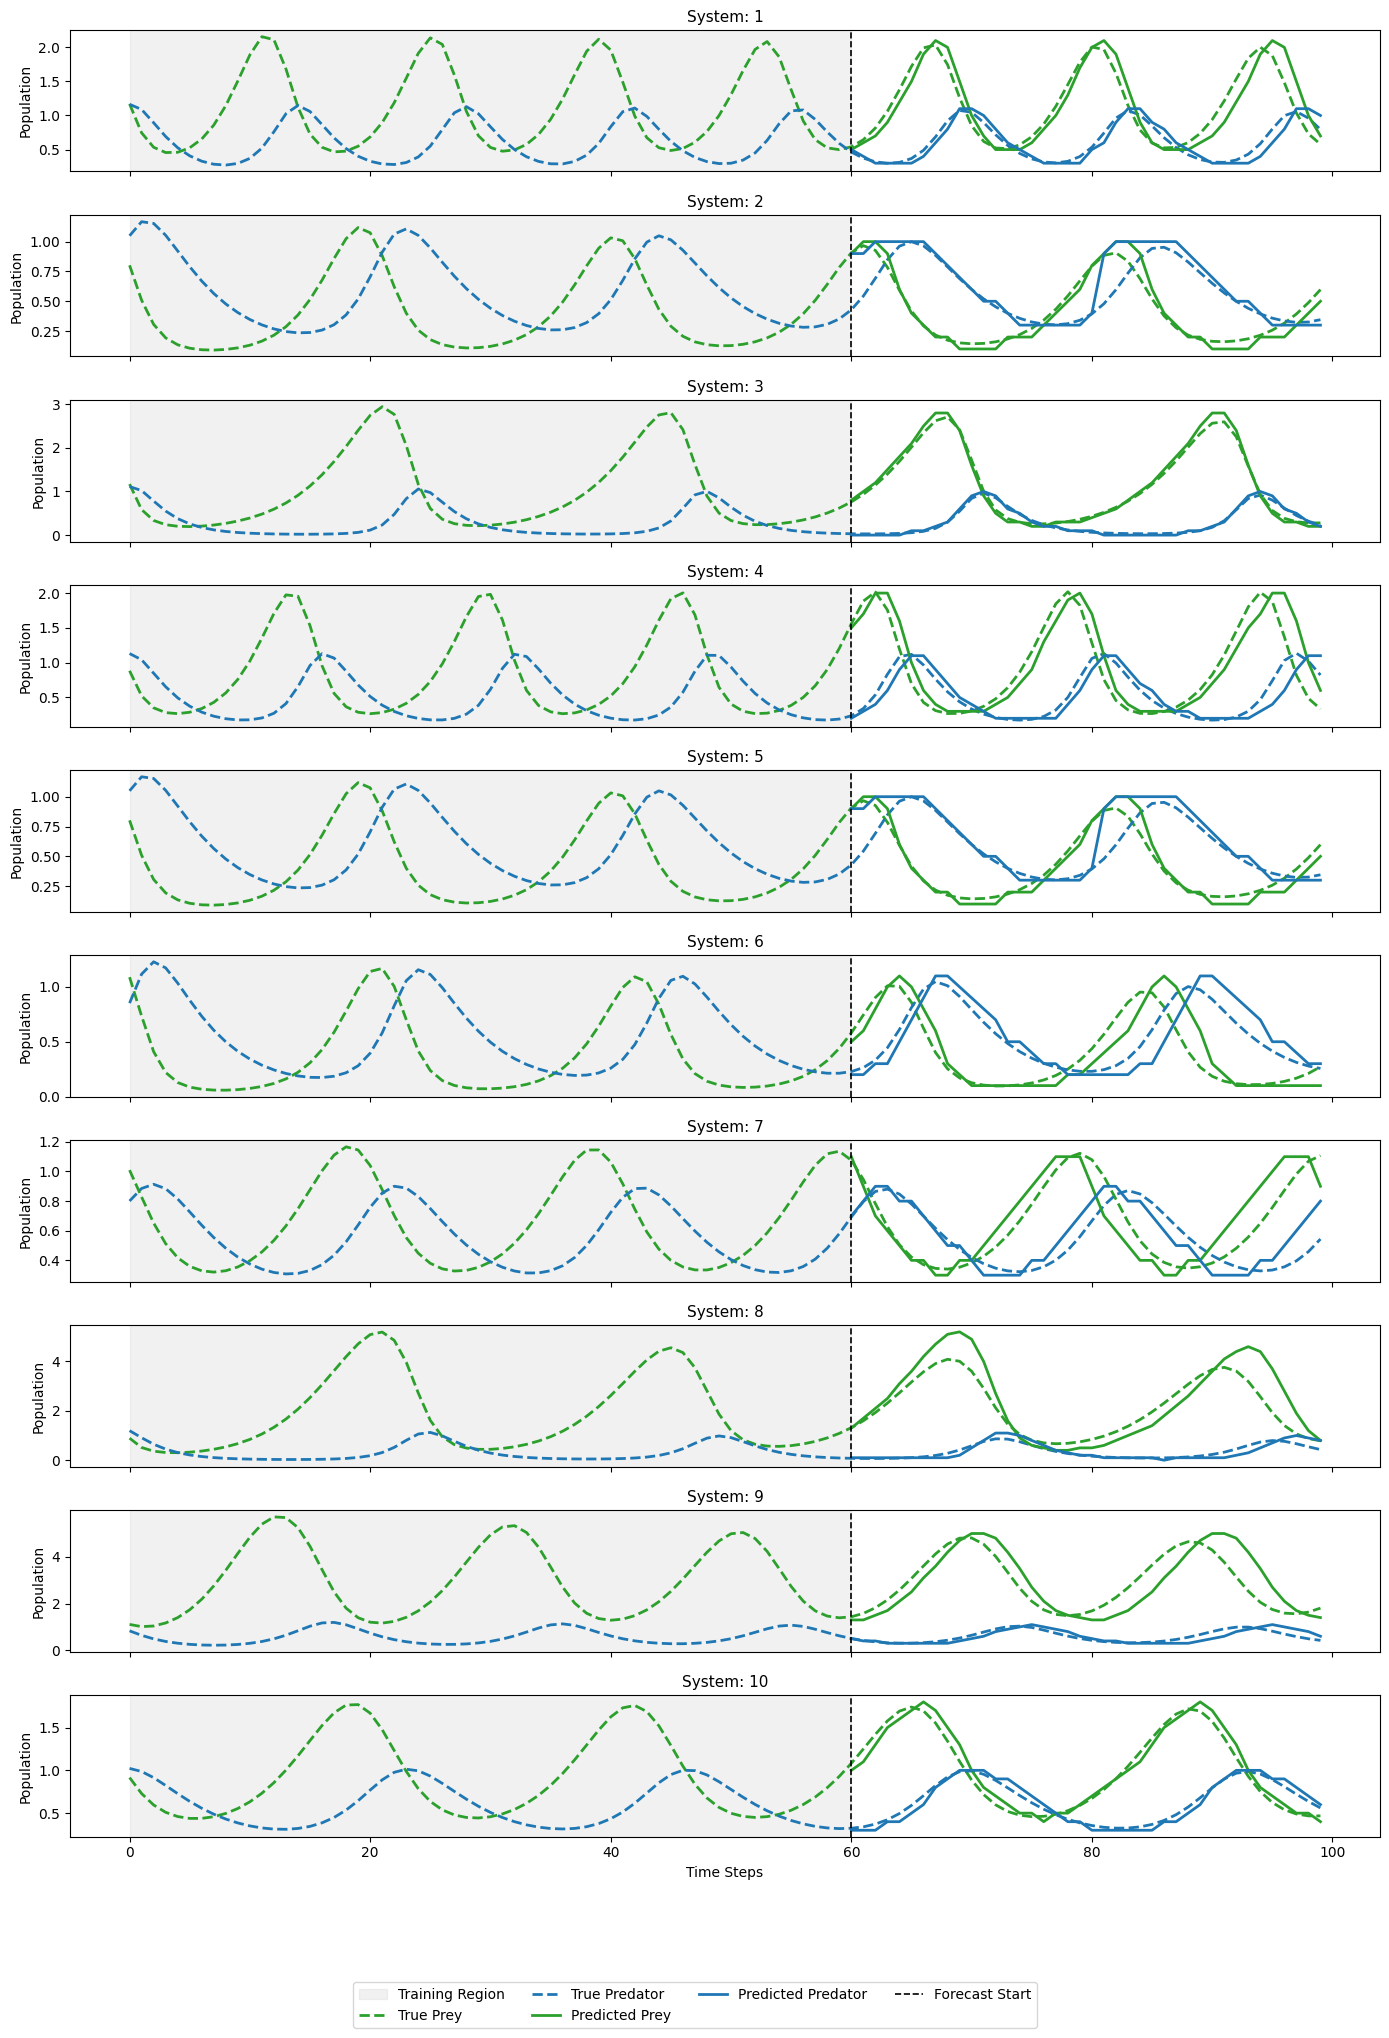

In [ ]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cpu")
model, tokenizer = load_qwen()
model.to(device)

# Inject LoRA layers
lora_rank = 4
for layer in model.model.layers:
    layer.self_attn.q_proj = LoRALinear(layer.self_attn.q_proj, r=lora_rank)
    layer.self_attn.v_proj = LoRALinear(layer.self_attn.v_proj, r=lora_rank)

# Load trained LoRA weights
model.load_state_dict(torch.load("../models/lora_qwen2.5_final_x2.pth", map_location="cpu"), strict=False)
model.eval()

# --- Load data
preprocessor = LLMTIMEPreprocessor()
trajectories = h5py.File("../lotka_volterra_data.h5", "r")["trajectories"][:]

true_predator_color = '#1f77b4'
pred_predator_color = '#1f77b4'
true_prey_color = '#2ca02c'
pred_prey_color = '#2ca02c'

systems = [300,900,814,584,900,884,869,516,560,573]
predictions_list = []

# --- 4x1 Grid Plot (Consistent styling)
fig, axs = plt.subplots(10, 1, figsize=(14, 20), sharex=True)
axs = axs.flatten()

index=1
for idx, system_id in enumerate(systems):
    sequence = trajectories[system_id, :, :]
    input_sequence = sequence[:60]
    true_output_sequence = sequence[60:]

    preprocessed_input = preprocessor.preprocess_sequence(input_sequence)
    tokenized_input = preprocessor.tokenize_sequence(preprocessed_input)
    input_tensor = torch.tensor([tokenized_input]).to(model.device)

    prediction = run_forecast(model, tokenizer, input_tensor, 1)

    # R squared
    true_prey = true_output_sequence[:, 0]
    true_predator = true_output_sequence[:, 1]
    pred_prey = prediction[:, 0]
    pred_predator = prediction[:, 1]

    r2_prey = r2_score(true_prey, pred_prey)
    r2_predator = r2_score(true_predator, pred_predator)

    print(f"{system_id}, R-squared for Prey: {r2_prey}")
    print(f"{system_id}, R-squared for Predator: {r2_predator}")
    

    predictions_list.append({
        "system_id": system_id,
        "predicted_prey": prediction[:, 0].tolist(),
        "predicted_predator": prediction[:, 1].tolist()
    })

    ax = axs[idx]
    # Shade training region
    ax.axvspan(0, 60, color='lightgrey', alpha=0.3, label="Training Region" if idx == 0 else None)

    # True values
    ax.plot(range(100), sequence[:, 0], label="True Prey", linestyle="--", color="#2ca02c", linewidth=2)
    ax.plot(range(100), sequence[:, 1], label="True Predator", linestyle="--", color="#1f77b4", linewidth=2)

    # Predictions
    forecast_range = range(60, 60 + len(prediction))
    ax.plot(forecast_range, prediction[:, 0], label="Predicted Prey", linestyle="-", color="#2ca02c", linewidth=2)
    ax.plot(forecast_range, prediction[:, 1], label="Predicted Predator", linestyle="-", color="#1f77b4", linewidth=2)

    # Forecast start
    ax.axvline(x=60, color='black', linestyle='--', lw=1.2, label="Forecast Start" if idx == 0 else None)

    ax.set_title(f"System: {index}", fontsize=11)
    ax.set_ylabel("Population")
    index+=1

axs[-1].set_xlabel("Time Steps")

# Shared legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.02), fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.suptitle("Predator-Prey Forecast vs Ground Truth (Trained Qwen)", fontsize=14, y=1.03)

plt.savefig("Trained_FINALFINAL.png", dpi=300, bbox_inches='tight')
plt.show()

df = pd.DataFrame(predictions_list)
df.to_csv("../csv/trainedFINALFINAL.csv", index=False)